# Arquitecturas aplicadas a clasificación de texto

Utilizaremos el dataset 20 Newsgroups para probar los modelos.

In [1]:
import codecs

import numpy as np
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

I0000 00:00:1775865165.588781 3587537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775865165.589397 3587537 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775865165.625211 3587537 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775865166.614636 3587537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# cargamos 20 Newsgroups
newsgroups_train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
newsgroups_test = fetch_20newsgroups(subset="test", remove=("headers", "footers", "quotes"))

In [4]:
# descargamos los embeddings de palabras de Fasttext para inglés y descomprimimos el archivo.
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
!unzip wiki-news-300d-1M.vec.zip

--2026-04-10 20:54:53--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 2600:9000:2371:da00:13:6e38:acc0:93a1, 2600:9000:2371:4a00:13:6e38:acc0:93a1, 2600:9000:2371:8a00:13:6e38:acc0:93a1, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|2600:9000:2371:da00:13:6e38:acc0:93a1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 681808098 (650M) [application/zip]
Saving to: ‘wiki-news-300d-1M.vec.zip’

wiki-news-300d-1M.v 100%[===================>] 650,22M  10,9MB/s    in 79s     

2026-04-10 20:56:13 (8,26 MB/s) - ‘wiki-news-300d-1M.vec.zip’ saved [681808098/681808098]

Archive:  wiki-news-300d-1M.vec.zip
  inflating: wiki-news-300d-1M.vec   


In [5]:
# cargamos los embeddings de palabras
print("loading word embeddings...")
embeddings_index = {}
f = codecs.open("wiki-news-300d-1M.vec", encoding="utf-8")

for line in f:
    values = line.rstrip().rsplit(" ")
    word = values[0]
    coefs = np.asarray(values[1:], dtype="float32")
    embeddings_index[word] = coefs
f.close()
print("found %s word vectors" % len(embeddings_index))

loading word embeddings...
found 999995 word vectors


In [7]:
print(newsgroups_train.data[16])


I certainly do use it whenever I have to do TIFF, and it usually works
very well.  That's not my point.  I'm >philosophically< opposed to it
because of its complexity.

This complexity has led to some programs' poor TIFF writers making
some very bizarre files, other programs' inability to load TIFF
images (though they'll save them, of course), and a general
inability to interchange images between different environments
despite the fact they all think they understand TIFF.

As the saying goes, "It's not me I'm worried about- it's all the
abuse of TIFF over the years, and I chalk it all up to the immense (and
unnecessary) complexity of the format.

In the words of the TIFF 5.0 spec, Appendix G, page G-1 (capitalized
emphasis mine):

"The only problem with this sort of success is that TIFF was designed
to be powerful and flexible, at the expense of simplicity.  It takes a
fair amount of effort to handle all the options currently defined in
this specification (PROBABLY NO APPLICATION DOES

In [8]:
# instanciamos el tokenizador
token = Tokenizer(
    num_words=30000,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=" ",
    char_level=False,
    oov_token="UNK",
    document_count=0,
)

In [9]:
# fiteamos el tokenizador
token.fit_on_texts(newsgroups_train.data)

In [11]:
# Creamos los indices para convertir de índices a palabras y viceversa
reverse_dictionary = token.index_word
dictionary = dict([(value, key) for (key, value) in reverse_dictionary.items()])

📝 A continuacion se acota el tamaño de los embeddings al número de palabras presentes en el vocabulario, para evitar cargar embeddings de palabras que no se encuentran en el dataset. Recodar que el vocabulario de FastText es de **1M**

In [12]:
# cargamos en una matriz los embeddings de las palabras
# presentes en el vocabulario
embed_dim = 300
num_words = len(dictionary) + 1
embedding_matrix = np.zeros([num_words, embed_dim])
for word, idx in dictionary.items():
    if idx <= num_words and word in embeddings_index:
        embedding_matrix[idx, :] = embeddings_index[word]

In [21]:
# se tokenizan los textos
train_sequences = token.texts_to_sequences(newsgroups_train.data)
test_sequences = token.texts_to_sequences(newsgroups_test.data)

In [22]:
len(train_sequences)

11314

In [23]:
train_sequences[0]

[8,
 27,
 1384,
 25,
 161,
 65,
 44,
 106,
 11323,
 62,
 16,
 15,
 313,
 8,
 588,
 2,
 74,
 263,
 12,
 27,
 6,
 30,
 1283,
 2508,
 313,
 987,
 4,
 17,
 31,
 2,
 1204,
 11908,
 749,
 13308,
 12,
 27,
 289,
 6,
 1,
 2,
 3722,
 69,
 173,
 409,
 9,
 1108,
 2,
 800,
 7711,
 27,
 1605,
 31,
 2,
 692,
 5,
 2,
 642,
 15,
 10,
 41,
 8,
 87,
 25,
 161,
 39,
 1,
 6,
 658,
 237,
 960,
 3070,
 180,
 5,
 2571,
 142,
 15,
 313,
 10,
 202,
 534,
 24,
 721,
 353,
 14,
 19,
 16,
 15,
 18060,
 358,
 313,
 168,
 102,
 207]

In [33]:
# El número de filas es el tamaño del vocabulario + 1 (para la palabra desconocida)
# y el número de columnas es igual a la dimensión de los embeddings.
embedding_matrix.shape

(105374, 300)

En este punto seleccionamos el tamaño de contexto a procesar en la variable `max_len`

In [25]:
max_len = 500
train_sequences = pad_sequences(train_sequences, maxlen=max_len)
test_sequences = pad_sequences(test_sequences, maxlen=max_len)

📝 El tamaño de la ventana de contexto va a influir en como se generan las secuencias. Si la secuencia es más corta que el tamaño de la ventana, se rellenará con ceros. Si es más larga, se truncará.

In [26]:
train_sequences[0]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

In [28]:
dictionary

{'UNK': 1,
 'the': 2,
 "'ax": 3,
 'to': 4,
 'of': 5,
 'a': 6,
 'and': 7,
 'i': 8,
 'in': 9,
 'is': 10,
 'that': 11,
 'it': 12,
 'for': 13,
 'you': 14,
 'this': 15,
 'on': 16,
 'be': 17,
 'are': 18,
 'have': 19,
 'with': 20,
 'not': 21,
 'as': 22,
 '1': 23,
 'or': 24,
 'if': 25,
 'but': 26,
 'was': 27,
 'they': 28,
 '0': 29,
 '2': 30,
 'from': 31,
 'by': 32,
 '3': 33,
 'at': 34,
 "'": 35,
 'x': 36,
 'm': 37,
 'an': 38,
 'can': 39,
 'will': 40,
 'all': 41,
 'my': 42,
 'one': 43,
 'there': 44,
 'what': 45,
 'would': 46,
 'do': 47,
 'he': 48,
 'we': 49,
 'about': 50,
 'q': 51,
 'has': 52,
 'so': 53,
 'your': 54,
 'no': 55,
 'some': 56,
 'any': 57,
 '4': 58,
 'max': 59,
 'which': 60,
 '5': 61,
 'me': 62,
 'w': 63,
 'who': 64,
 'out': 65,
 '7': 66,
 'more': 67,
 'p': 68,
 'were': 69,
 'people': 70,
 'their': 71,
 'when': 72,
 'like': 73,
 'other': 74,
 'r': 75,
 "don't": 76,
 'g': 77,
 'up': 78,
 'just': 79,
 's': 80,
 '8': 81,
 'get': 82,
 'only': 83,
 '6': 84,
 'them': 85,
 'had': 86,
 'kn

In [29]:
token.index_word

{1: 'UNK',
 2: 'the',
 3: "'ax",
 4: 'to',
 5: 'of',
 6: 'a',
 7: 'and',
 8: 'i',
 9: 'in',
 10: 'is',
 11: 'that',
 12: 'it',
 13: 'for',
 14: 'you',
 15: 'this',
 16: 'on',
 17: 'be',
 18: 'are',
 19: 'have',
 20: 'with',
 21: 'not',
 22: 'as',
 23: '1',
 24: 'or',
 25: 'if',
 26: 'but',
 27: 'was',
 28: 'they',
 29: '0',
 30: '2',
 31: 'from',
 32: 'by',
 33: '3',
 34: 'at',
 35: "'",
 36: 'x',
 37: 'm',
 38: 'an',
 39: 'can',
 40: 'will',
 41: 'all',
 42: 'my',
 43: 'one',
 44: 'there',
 45: 'what',
 46: 'would',
 47: 'do',
 48: 'he',
 49: 'we',
 50: 'about',
 51: 'q',
 52: 'has',
 53: 'so',
 54: 'your',
 55: 'no',
 56: 'some',
 57: 'any',
 58: '4',
 59: 'max',
 60: 'which',
 61: '5',
 62: 'me',
 63: 'w',
 64: 'who',
 65: 'out',
 66: '7',
 67: 'more',
 68: 'p',
 69: 'were',
 70: 'people',
 71: 'their',
 72: 'when',
 73: 'like',
 74: 'other',
 75: 'r',
 76: "don't",
 77: 'g',
 78: 'up',
 79: 'just',
 80: 's',
 81: '8',
 82: 'get',
 83: 'only',
 84: '6',
 85: 'them',
 86: 'had',
 87:

## 1) Suma de embeddings + MLP

In [34]:
from keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dropout,
    Dense,
    Lambda,
    Concatenate,
    Input,
)
from keras.models import Sequential, Model
import tensorflow.keras.backend as K
import keras

In [35]:
class F1Callback(keras.callbacks.Callback):
    """
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    """

    def __init__(self, X_val, y_val, num_classes, history_f1, patience=5):
        # El callback lo inicializamos con secuencias de validación sobre las cuales
        # mediremos la perplejidad
        self.X_val = X_val
        self.y_val = y_val

        self.max_score = 0
        self.num_classes = num_classes
        self.epsilon = 10e-8
        self.patience = patience
        self.patience_counter = 0

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.X_val, verbose=0)

        y_pred = np.argmax(predictions, axis=1)

        counter = np.zeros((self.num_classes, self.num_classes))

        for idx_pred, idx_true in zip(y_pred, self.y_val):
            counter[idx_pred, idx_true] += 1

        # sea calcula TP, FN y FP
        TP = np.diag(counter)
        FN = counter.sum(axis=0) - TP
        FP = counter.sum(axis=1) - TP

        precision = TP / (TP + FP + self.epsilon)
        recall = TP / (TP + FN + self.epsilon)

        # se calcula el F1-sscore
        f1 = 2 * precision * recall / (precision + recall + self.epsilon)

        current_score = np.mean(f1)

        history_f1.append(current_score)

        print(f"\n f1 macro: {current_score} \n")

        # chequeamos si tenemos que  detener el entrenamiento
        if current_score > self.max_score:
            self.max_score = current_score
            self.model.save("my_model.keras")
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == 5:
                print("Stopping training...")
                self.model.stop_training = True

In [38]:
nb_words = num_words

model = Sequential()

model.add(Input(shape=(max_len,)))
model.add(
    Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        # input_length=max_len,
        trainable=False,
    )
)
model.add(Lambda(lambda x: K.sum(x, axis=1)))  # Suma de los embeddings

model.add(Dense(32, activation="relu"))
model.add(Dense(20, activation="softmax"))  # multi-label (k-hot encoding)

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 300)       │    31,612,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,622,492 (120.63 MB)

 Trainable params: 10,292 (40.20 KB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [39]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=64,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40
173/177 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0868 - loss: 5.9591
 f1 macro: 0.139502790391498 

Saved new model!
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1173 - loss: 3.8323
Epoch 2/40
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2052 - loss: 2.6227
 f1 macro: 0.2924772760062155 

Saved new model!
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2382 - loss: 2.5306
Epoch 3/40
172/177 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3559 - loss: 2.1677
 f1 macro: 0.38721781203375555 

Saved new model!
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3797 - loss: 2.0821
Epoch 4/40
173/177 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4523 - loss: 1.8438
 f1 macro: 0.43220111206751427 

Saved new model!
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4680 - loss: 1.7857
Epoch 5/40
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5053 - loss: 1.6382
 f1 macro: 0.4715858781499403 

Saved new model!
177/177 ━━━━━━━━━━━━

In [40]:
import seaborn as sns

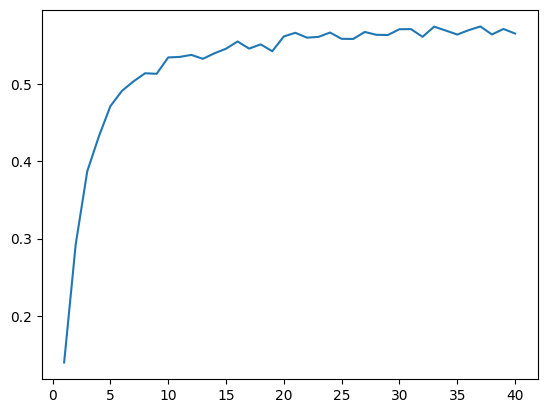

In [41]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()

## 2) Clasificador Embeddings + CNN

📝 En la practica se usa varios kernels donde cada uno aprende una característica diferente del texto.

In [ ]:
nb_words = num_words
num_filters = 64

model = Sequential()

model.add(Input(shape=(max_len,)))
model.add(
    Embedding(input_dim=nb_words, output_dim=embed_dim, weights=[embedding_matrix], trainable=False)
)

model.add(Conv1D(num_filters, 7, activation="relu", padding="same"))
model.add(MaxPooling1D(2))

model.add(Conv1D(num_filters * 2, 7, activation="relu", padding="same"))
model.add(
    GlobalMaxPooling1D()
)  # Aplana la salida a un vector de num_filters*2 que condensa la información
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(Dense(20, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 500, 300)       │    31,612,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 500, 64)        │       134,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 250, 128)       │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,808,924 (121.34 MB)

 Trainable params: 196,724 (768.45 KB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [44]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=128,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.0618 - loss: 2.9865
 f1 macro: 0.08808518438467208 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.0790 - loss: 2.9367
Epoch 2/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1906 - loss: 2.4546
 f1 macro: 0.3460577575793259 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.2347 - loss: 2.2739
Epoch 3/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3430 - loss: 1.8819
 f1 macro: 0.42984114484781283 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.3766 - loss: 1.7828
Epoch 4/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4654 - loss: 1.5408
 f1 macro: 0.48452122276374815 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.4701 - loss: 1.5261
Epoch 5/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5272 - loss: 1.3770
 f1 macro: 0.5028983366137663 

Saved new model!
89/89 ━━━━━━━━━━━━━

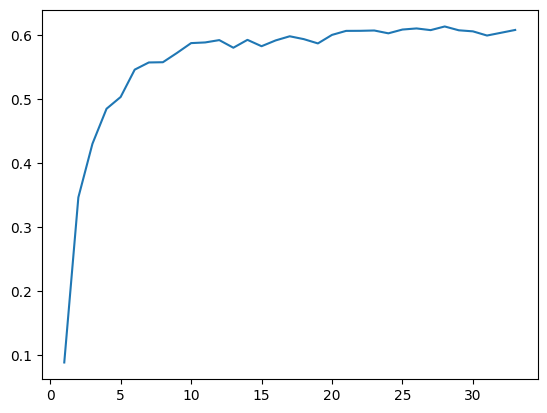

In [45]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()

## 3) Clasificación con TextCNN


📝 Para generar la arquitectura TextCNN se utiliza la notación funcional de Keras, que permite crear modelos más flexibles. En este caso, se crean tres ramas convolucionales con diferentes tamaños de kernel (4, 3 y 2) para capturar diferentes patrones en el texto. Luego, se concatenan las salidas de estas ramas y se pasan por una capa densa para la clasificación.

In [47]:
nb_words = num_words
num_filters = 64

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(
    input_dim=nb_words, output_dim=embed_dim, weights=[embedding_matrix], trainable=False
)(input_layer)

conv4 = Conv1D(num_filters, 4, activation="relu", padding="same")(embedding_layer)
conv3 = Conv1D(num_filters, 3, activation="relu", padding="same")(embedding_layer)
conv2 = Conv1D(num_filters, 2, activation="relu", padding="same")(embedding_layer)
pool4 = GlobalMaxPooling1D()(conv4)
pool3 = GlobalMaxPooling1D()(conv3)
pool2 = GlobalMaxPooling1D()(conv2)
added = Concatenate()([pool4, pool3, pool2])

dense1 = Dense(32, activation="relu")(added)
dense2 = Dense(20, activation="softmax")(dense1)

model = Model(input_layer, dense2)

# adam = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 500, 300)  │ 31,612,200 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 500, 64)   │     76,864 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 500, 64)   │     57,664 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 500, 64)   │     38,464 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_8[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_9[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      6,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 20)        │        660 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,792,028 (121.28 MB)

 Trainable params: 179,828 (702.45 KB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [48]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=128,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1472 - loss: 2.8896
 f1 macro: 0.36338673624335527 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.2484 - loss: 2.6936
Epoch 2/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5303 - loss: 1.8144
 f1 macro: 0.5661203265889905 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.5757 - loss: 1.6103
Epoch 3/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6660 - loss: 1.1769
 f1 macro: 0.6092290992993108 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.6783 - loss: 1.1331
Epoch 4/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7210 - loss: 0.9557
 f1 macro: 0.6115681013501708 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.7280 - loss: 0.9357
Epoch 5/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7704 - loss: 0.8008
 f1 macro: 0.627766851429131 

Saved new model!
89/89 ━━━━━━━━━━━━━━━

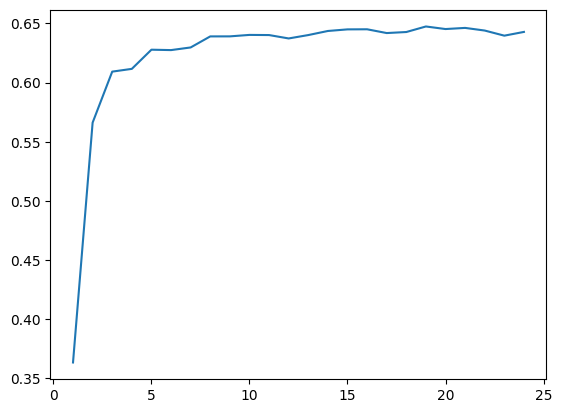

In [49]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()

## 4) MLP + Embeddings + Attention

In [50]:
from keras.layers import RepeatVector, TimeDistributed, Multiply, Lambda, Activation, Reshape
from keras.activations import softmax

In [52]:
def softMaxOverTime(x):
    return softmax(x, axis=1)


key_dim = 50
nb_words = num_words
num_filters = 64

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(
    input_dim=nb_words, output_dim=embed_dim, weights=[embedding_matrix], trainable=False
)(input_layer)

dense_input = Dense(key_dim, activation="tanh")(embedding_layer)
ulog_attention = Dense(1, activation="linear")(dense_input)

attention = Activation(softMaxOverTime)(ulog_attention)

# A continuación, se repite el vector de atención para cada dimensión del embedding.
repeated_attention = TimeDistributed(RepeatVector(embed_dim))(attention)

repeated_attention = Reshape([max_len, embed_dim])(repeated_attention)

weighted_embeddings = Multiply()([repeated_attention, embedding_layer])
embedding_sum = Lambda(lambda x: K.sum(x, axis=1), output_shape=(300,))(weighted_embeddings)

dense1 = Dense(32, activation="relu")(embedding_sum)
dense2 = Dense(20, activation="softmax")(dense1)

model = Model(input_layer, dense2)

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 500, 300)  │ 31,612,200 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 500, 50)   │     15,050 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 500, 1)    │         51 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 500, 1)    │          0 │ dense_19[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 500, 300,  │          0 │ activation_1[0][… │
│ (TimeDistributed)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 500, 300)  │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 500, 300)  │          0 │ reshape_1[0][0],  │
│ (Multiply)          │                   │            │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 300)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 32)        │      9,632 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 20)        │        660 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,637,593 (120.69 MB)

 Trainable params: 25,393 (99.19 KB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [53]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=128,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40


E0000 00:00:1775943706.821366 3587537 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.0888 - loss: 2.9686
 f1 macro: 0.2754141145167169 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 57s 328ms/step - accuracy: 0.1607 - loss: 2.8859
Epoch 2/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4342 - loss: 2.2396
 f1 macro: 0.49451255498166996 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.4800 - loss: 2.0175
Epoch 3/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5447 - loss: 1.6278
 f1 macro: 0.5257941703775261 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.5582 - loss: 1.5659
Epoch 4/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5716 - loss: 1.4748
 f1 macro: 0.5385110992911988 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.5808 - loss: 1.4349
Epoch 5/40
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6058 - loss: 1.3544
 f1 macro: 0.5496676377009128 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 13

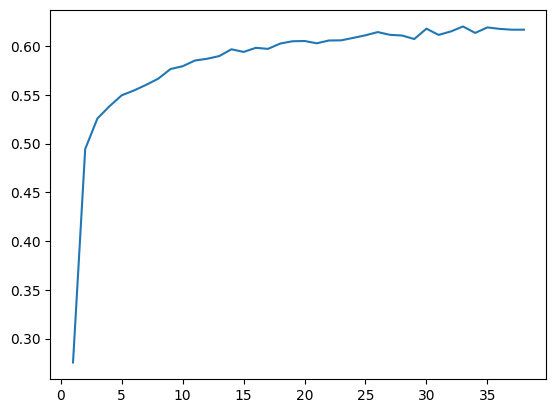

In [54]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()

## 5) MLP + Embeddings + Attention + CNN

In [56]:
value_dim = 100


def softMaxOverTime(x):
    return softmax(x, axis=1)


nb_words = num_words
num_filters = 64

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(
    input_dim=nb_words, output_dim=embed_dim, weights=[embedding_matrix], trainable=False
)(input_layer)

conv_out = Conv1D(value_dim, 8, padding="same")(embedding_layer)
conv_out = Activation("relu")(conv_out)
# conv_out=Conv1D(value_dim,8,activation="relu",padding="same")(conv_out)
conv_out = Conv1D(value_dim, 8, activation="tanh", padding="same")(conv_out)

ulog_attention = Dense(1, activation="linear")(conv_out)
attention = Activation(softMaxOverTime)(ulog_attention)
repeated_attention = TimeDistributed(RepeatVector(value_dim))(attention)
repeated_attention = Reshape([max_len, value_dim])(repeated_attention)
weighted_embeddings = Multiply()([repeated_attention, conv_out])
embedding_sum = Lambda(lambda x: K.sum(x, axis=1), output_shape=(100,))(weighted_embeddings)

dense1 = Dense(100, activation="relu")(embedding_sum)
dense2 = Dense(20, activation="softmax")(dense1)

model = Model(input_layer, dense2)

# adam = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 500, 300)  │ 31,612,200 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 500, 100)  │    240,100 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 500, 100)  │          0 │ conv1d_12[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 500, 100)  │     80,100 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 500, 1)    │        101 │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 500, 1)    │          0 │ dense_25[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 500, 100,  │          0 │ activation_5[0][… │
│ (TimeDistributed)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 500, 100)  │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 500, 100)  │          0 │ reshape_3[0][0],  │
│ (Multiply)          │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 100)       │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 100)       │     10,100 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 20)        │      2,020 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,944,621 (121.86 MB)

 Trainable params: 332,421 (1.27 MB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [57]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=128,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.1363 - loss: 2.7373
 f1 macro: 0.3419058325060039 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 81s 556ms/step - accuracy: 0.2461 - loss: 2.3556
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4934 - loss: 1.5074
 f1 macro: 0.5243745765824549 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 32s 355ms/step - accuracy: 0.5274 - loss: 1.4073
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6121 - loss: 1.1692
 f1 macro: 0.5565825273436784 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 35s 396ms/step - accuracy: 0.6275 - loss: 1.1348
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6737 - loss: 0.9850
 f1 macro: 0.5815810024189495 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 34s 378ms/step - accuracy: 0.6777 - loss: 0.9836
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7215 - loss: 0.8546
 f1 macro: 0.6041294529313681 

Saved new model!
89/89 ━━━━━━━━━━━━━━━

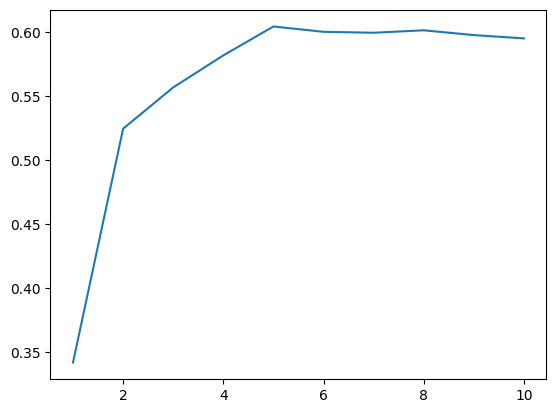

In [58]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()

## 6) Bidir RNN + Attention

In [75]:
from keras.layers import Bidirectional, LSTM

value_dim = 100


def softMaxOverTime(x):
    return softmax(x, axis=1)


nb_words = num_words
num_filters = 64

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(
    input_dim=nb_words, output_dim=embed_dim, weights=[embedding_matrix], trainable=False
)(input_layer)
# lstm_out=Bidirectional(LSTM(value_dim, return_sequences=True))(embedding_layer)
# lstm_out=Bidirectional(LSTM(value_dim, return_sequences=True))(lstm_out)
# lstm_out=Bidirectional(LSTM(value_dim, return_sequences=True,activation="relu"),merge_mode="sum")(embedding_layer)
lstm_out = Bidirectional(
    LSTM(value_dim, return_sequences=True, activation="tanh"), merge_mode="sum"
)(embedding_layer)

ulog_attention = Dense(1, activation="linear")(lstm_out)
attention = Activation(softMaxOverTime)(ulog_attention)
repeated_attention = TimeDistributed(RepeatVector(value_dim))(attention)
repeated_attention = Reshape([max_len, value_dim])(repeated_attention)
weighted_embeddings = Multiply()([repeated_attention, lstm_out])
# embedding_sum = Lambda(lambda x: K.sum(x, axis=1),output_shape=(None,value_dim))(weighted_embeddings)
embedding_sum = Lambda(lambda x: K.sum(x, axis=1), output_shape=(value_dim,))(weighted_embeddings)

dense1 = Dense(100, activation="relu")(embedding_sum)
dense2 = Dense(20, activation="softmax")(dense1)

model = Model(input_layer, dense2)

# adam = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
# model.compile(loss='sparse_categorical_crossentropy', optimizer="rmsprop", metrics=['accuracy'])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])


model.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_22        │ (None, 500, 300)  │ 31,612,200 │ input_layer_20[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 500, 100)  │    320,800 │ embedding_22[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 500, 1)    │        101 │ bidirectional_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 500, 1)    │          0 │ dense_61[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_15 │ (None, 500, 100,  │          0 │ activation_17[0]… │
│ (TimeDistributed)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_15          │ (None, 500, 100)  │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 500, 100)  │          0 │ reshape_15[0][0], │
│ (Multiply)          │                   │            │ bidirectional_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 100)       │          0 │ multiply_15[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 100)       │     10,100 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 20)        │      2,020 │ dense_62[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,945,221 (121.86 MB)

 Trainable params: 333,021 (1.27 MB)

 Non-trainable params: 31,612,200 (120.59 MB)

In [76]:
history_f1 = []
model.fit(
    train_sequences,
    newsgroups_train.target,
    batch_size=128,
    epochs=40,
    callbacks=[F1Callback(test_sequences, newsgroups_test.target, 20, history_f1)],
)

Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.0868 - loss: 2.9022
 f1 macro: 0.14009476615193567 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 99s 784ms/step - accuracy: 0.1146 - loss: 2.7757
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.2101 - loss: 2.3781
 f1 macro: 0.2798873918652438 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 55s 617ms/step - accuracy: 0.2511 - loss: 2.2474
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.3767 - loss: 1.8543
 f1 macro: 0.4302917350205383 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 57s 638ms/step - accuracy: 0.4120 - loss: 1.7413
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.4974 - loss: 1.4725
 f1 macro: 0.47974285693704155 

Saved new model!
89/89 ━━━━━━━━━━━━━━━━━━━━ 57s 638ms/step - accuracy: 0.5112 - loss: 1.4512
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.5658 - loss: 1.3066
 f1 macro: 0.5483510672215166 

Saved new model!
89/89 ━━━━━━━━━━━━━

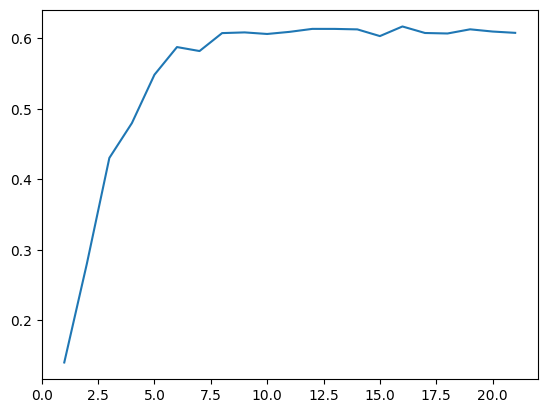

In [77]:
# Entrenamiento
epoch_count = range(1, len(history_f1) + 1)
sns.lineplot(x=epoch_count, y=history_f1)
plt.show()